In [1]:
%load_ext autoreload
%autoreload 2

Params

---
1k

GMP: "gmp_degree": 6

LSTM: "hidden_size": 15, 
    "num_layers": 1,
    "bidirectional": False,

GRU: "hidden_size": 16, 
    "num_layers": 1,
    "bidirectional": False,

RTDTNN: "M": 6,
        "P": 6,
        "d_in": P+2,
        "d_model": 10,
        "n_heads": 2,
        "d_ff": 10,
        "n_fc": 2,

LEANN:  "M": 6,
        "L1": 16,
        "L2": 8,
        "L3": 16,
        "K": 3,

PLEANN: "M": M,
        "L1": 16,
        "L2": 8,
        "L3": 16,
        "K": 3,
        "lr": 0.001,
        "lr2": 0.0001,
        "epochs": 300,
        "epochs2": 200,
        "lambda_reg": 1e-3,
        "alpha": 0.003,
        "tau": 0.002,

---

2k

GMP: "gmp_degree": 8

LSTM:

GRU:

RTDTNN:

LEANN:

PLEANN

TCN:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from modules import data_loader, metrics, plotting, utils, params, learning, prunning
from models.gmp import GMP
from models.gru import GRU, KPGRU
from models.lstm import LSTM, KPLSTM
from models.rtdtnn import RTDTNN
from models.leann import LEANN
from models.tcn import TCN, KPTCN
from modules.pipelines import SimplePipeline


Load data from files and init acpr meter

In [3]:
M = 5
P = 3

container = data_loader.DataContainer()
container.load_data(file_path="datasets/Custom_dataset")
container.cut_signals(M=M)
container.get_gained_signals()


acpr_meter = metrics.ACPR(
        sample_rate=container.input_signal_fs,
        main_measurement_bandwidth=container.bw_main_ch,
        adjacent_channel_offset=[-container.sub_ch, container.sub_ch],
        segment_length=container.nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=container.nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )


PA MODEL

In [4]:
gmp_train_props = {
    "gmp_degree": 6,
    "lr": 0.001,
    "epochs": 200,
    "acpr_meter": acpr_meter
}

pa_gmp_pipeline = SimplePipeline(container=container, 
                                 train_props=gmp_train_props, 
                                 base_model=GMP)

pa_gmp_pipeline.run_pa()
pa_model = pa_gmp_pipeline.get_pa_model()

pa_results = pa_gmp_pipeline.get_results()

gmp_pa_nmse = pa_results["pa"]["nmse"]
pa_acpr = pa_results["pa"]["acpr"]
y_val_pa = pa_results["pa"]["y_val_pa_model"]


Run PA
count_params: 936
count_flops: 5652
count_macs: 2103
Model weights loaded from model_params/pa_GMP_Ka6_La6_Kb6_Lb6_Mb6_Kc6_Lc6_Mc6.pt
[PA] NMSE: -40.75, ACPR: -41.20 -40.75


GMP

In [5]:
gmp_train_props = {
    "gmp_degree": 8,
    "lr": 0.01,
    "epochs": 200,
    "acpr_meter": acpr_meter
}

gmp_pipeline = SimplePipeline(container=container, 
                              train_props=gmp_train_props, 
                              base_model=GMP,
                              pa_model=pa_model)


In [6]:

gmp_stats = gmp_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

gmp_agg_stats = metrics.summarize_statistics(gmp_stats)

gmp_results = gmp_pipeline.get_results()

gmp_count = gmp_results["ilc"]["count_params"]

final_gmp_stats = {
        "Model": "GMP",
        "Params": gmp_count,
        "FLOPs": gmp_results["ilc"]["count_flops"],
        "NMSE (dB)": round(gmp_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(gmp_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(gmp_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_gmp_stats)


=== Run 1/5 ===
Run ILC
count_params: 2176
count_macs: 5981
count_flops: 12736
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:54
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:28
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.00001231, val_loss: 0.00000021, val_NMSE: -31.96, lr: 0.01
Epoch 0001 — train_loss: 0.00000041, val_loss: 0.00000014, val_NMSE: -33.77, lr: 0.01
Epoch 0002 — train_loss: 0.00000072, val_loss: 0.00000027, val_NMSE: -30.88, lr: 0.01
Epoch 0003 — train_loss: 0.00000090, val_loss: 0.00000007, val_NMSE: -36.62, lr: 0.01
Epoch 0004 — train_loss: 0.00000084, val_loss: 0.00000009, val_NMSE: -35.72, lr: 0.01
Epoch 0005 — train_loss: 0.00000143, val_loss: 0.00000008, val_NMSE: -36.41, lr: 0.01
Unexpected exception for

Traceback (most recent call last):
  File "c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\maximp\AppData\Local\Temp\ipykernel_3852\4013900019.py", line 1, in <module>
    gmp_stats = gmp_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)
  File "d:\Учёба\проект\python\DPD_Research\modules\pipelines.py", line 503, in evaluate_with_statistics
  File "d:\Учёба\проект\python\DPD_Research\modules\pipelines.py", line 336, in run_ilc
    learning.train(net=self.ilc_model,
  File "d:\Учёба\проект\python\DPD_Research\modules\utils.py", line 141, in wrapper
    result = func(*args, **kwargs)
  File "d:\Учёба\проект\python\DPD_Research\modules\learning.py", line 78, in train
    net, train_loss = net_train(net=net,
  File "d:\Учёба\проект\python\DPD_Research\modules\learning.py", line 35, in net_train
    out = net(features)
  File "c:\Us

KPGRU

In [14]:

kpgru_train_props = {
    "M": M,
    "hidden_size": 10,
    "num_layers": 1,
    "bidirectional": False,
    "reduced_dim": 8,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

kpgru_pipeline = SimplePipeline(container=container, 
                              train_props=kpgru_train_props, 
                              base_model=KPGRU,
                              pa_model=pa_model)


In [ ]:

kpgru_stats = kpgru_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

kpgru_agg_stats = metrics.summarize_statistics(kpgru_stats)

kpgru_results = kpgru_pipeline.get_results()

kpgru_count = kpgru_results["ilc"]["count_params"]

final_kpgru_stats = {
        "Model": "KPGRU",
        "Params": kpgru_count,
        "FLOPs": kpgru_results["ilc"]["count_flops"],
        "NMSE (dB)": round(kpgru_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(kpgru_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(kpgru_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_kpgru_stats)


=== Run 1/5 ===
Run ILC
count_params: 2046
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.03085936, val_loss: 0.00117567, val_NMSE: -28.73, lr: 0.01
Epoch 0001 — train_loss: 0.00120833, val_loss: 0.00039293, val_NMSE: -33.49, lr: 0.01
Epoch 0002 — train_loss: 0.00074243, val_loss: 0.00026704, val_NMSE: -35.17, lr: 0.01
Epoch 0003 — train_loss: 0.00057281, val_loss: 0.00019461, val_NMSE: -36.54, lr: 0.01
Epoch 0004 — train_loss: 0.00049054, val_loss: 0.00013287, val_NMSE: -38.20, lr: 0.01
Epoch 0005 — train_loss: 0.00043155, val_loss: 0.00023293, val_NMSE: -35.76, lr: 0.01
Epoch 0006 — train_loss: 0.00037423, val_loss: 0.00019775, val_NMSE: -36.47, lr: 0.01
Epoch 0007 — train_loss: 0.00036811, val_loss: 0.00010323, val_NMSE: -39.30, lr: 0.01
Epoch 0008 — train_loss: 0.00030815, val_loss: 0.00009508, val_NMSE: -39.65, lr: 0.01
Epoch 0009 — train_loss: 0.00028992, val_loss: 0.00010167, val_NMSE: -39.36, lr: 0.01
Epoch 0010 — train_loss: 0.00026438,

KPLSTM

In [26]:

kplstm_train_props = {
    "M": M,
    "hidden_size": 8,
    "num_layers": 1,
    "reduced_dim": 8,
    "bidirectional": False,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

kplstm_pipeline = SimplePipeline(container=container, 
                              train_props=kplstm_train_props, 
                              base_model=KPLSTM,
                              pa_model=pa_model)


In [ ]:

kplstm_stats = kplstm_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

kplstm_agg_stats = metrics.summarize_statistics(kplstm_stats)

kplstm_results = kplstm_pipeline.get_results()

kplstm_count = kplstm_results["ilc"]["count_params"]

final_kplstm_stats = {
        "Model": "KPLSTM",
        "Params": kplstm_count,
        "FLOPs": kplstm_results["ilc"]["count_flops"],
        "NMSE (dB)": round(kplstm_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(kplstm_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(kplstm_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_kplstm_stats)


=== Run 1/5 ===
Run ILC
count_params: 2018
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.05240492, val_loss: 0.00215148, val_NMSE: -26.11, lr: 0.01
Epoch 0001 — train_loss: 0.00251719, val_loss: 0.00097686, val_NMSE: -29.54, lr: 0.01
Epoch 0002 — train_loss: 0.00142079, val_loss: 0.00052916, val_NMSE: -32.20, lr: 0.01
Epoch 0003 — train_loss: 0.00098797, val_loss: 0.00036445, val_NMSE: -33.82, lr: 0.01
Epoch 0004 — train_loss: 0.00078399, val_loss: 0.00027927, val_NMSE: -34.97, lr: 0.01
Epoch 0005 — train_loss: 0.00064773, val_loss: 0.00029365, val_NMSE: -34.76, lr: 0.01
Epoch 0006 — train_loss: 0.00054699, val_loss: 0.00046678, val_NMSE: -32.74, lr: 0.01
Epoch 0007 — train_loss: 0.00052707, val_loss: 0.00023009, val_NMSE: -35.81, lr: 0.01
Epoch 0008 — train_loss: 0.00045298, val_loss: 0.00016338, val_NMSE: -37.30, lr: 0.01
Epoch 0009 — train_loss: 0.00042687, val_loss: 0.00015876, val_NMSE: -37.43, lr: 0.01
Epoch 0010 — train_loss: 0.00039888,

KPTCN

In [5]:

kptcn_train_props = {
    "M": M,
    "hidden_channels": 22,
    "kernel_size": 4,
    "reduced_dim": 8,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

kptcn_pipeline = SimplePipeline(container=container, 
                              train_props=kptcn_train_props, 
                              base_model=KPTCN,
                              pa_model=pa_model)


In [ ]:

kptcn_stats = kptcn_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

kptcn_agg_stats = metrics.summarize_statistics(kptcn_stats)

kptcn_results = kptcn_pipeline.get_results()

kptcn_count = kptcn_results["ilc"]["count_params"]

final_kptcn_stats = {
        "Model": "KPTCN",
        "Params": kptcn_count,
        "FLOPs": kptcn_results["ilc"]["count_flops"],
        "NMSE (dB)": round(kptcn_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(kptcn_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(kptcn_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_kptcn_stats)


=== Run 1/5 ===
Run ILC
count_params: 2036
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:02:18
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:26
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.12233300, val_loss: 0.00036203, val_NMSE: -33.85, lr: 0.01
Epoch 0001 — train_loss: 0.00075551, val_loss: 0.00028219, val_NMSE: -34.93, lr: 0.01
Epoch 0002 — train_loss: 0.00051836, val_loss: 0.00015332, val_NMSE: -37.58, lr: 0.01
Epoch 0003 — train_loss: 0.00042295, val_loss: 0.00012566, val_NMSE: -38.44, lr: 0.01
Epoch 0004 — train_loss: 0.00035117, val_loss: 0.00007298, val_NMSE: -40.80, lr: 0.01
Epoch 0005 — train_loss: 0.00030633, val_loss: 0.00008038, val_NMSE: -40.38, lr: 0.01
Epoch 0006 — train_loss: 0.00026395, val_loss: 0.00007158, v

TCN

In [7]:

tcn_train_props = {
    "hidden_channels": 96,
    "kernel_size": 4,
    "lr": 0.001,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

tcn_pipeline = SimplePipeline(container=container, 
                              train_props=tcn_train_props, 
                              base_model=TCN,
                              pa_model=pa_model)


In [ ]:

tcn_stats = tcn_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

tcn_agg_stats = metrics.summarize_statistics(tcn_stats)

tcn_results = tcn_pipeline.get_results()

tcn_count = tcn_results["ilc"]["count_params"]

final_tcn_stats = {
        "Model": "TCN",
        "Params": tcn_count,
        "FLOPs": tcn_results["ilc"]["count_flops"],
        "NMSE (dB)": round(tcn_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(tcn_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(tcn_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_tcn_stats)


=== Run 1/5 ===
Run ILC
count_params: 2016
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.01423291, val_loss: 0.00374876, val_NMSE: -23.69, lr: 0.001
Epoch 0001 — train_loss: 0.00436729, val_loss: 0.00119917, val_NMSE: -28.64, lr: 0.001
Epoch 0002 — train_loss: 0.00240702, val_loss: 0.00060799, val_NMSE: -31.59, lr: 0.001
Epoch 0003 — train_loss: 0.00151766, val_loss: 0.00033859, val_NMSE: -34.14, lr: 0.001
Epoch 0004 — train_loss: 0.00096331, val_loss: 0.00019418, val_NMSE: -36.55, lr: 0.001
Epoch 0005 — train_loss: 0.00073770, val_loss: 0.00014259, val_NMSE: -37.89, lr: 0.001
Epoch 0006 — train_loss: 0.00065518, val_loss: 0.00011679, val_NMSE: -38.76, lr: 0.001
Epoch 0007 — train_loss: 0.00061236, val_loss: 0.00010321, val_NMSE: -39.30, lr: 0.001
Epoch 0008 — train_loss: 0.00058569, val_loss: 0.00009298, val_NMSE: -39.75, lr: 0.001
Epoch 0009 — train_loss: 0.00056567, val_loss: 0.00008849, val_NMSE: -39.96, lr: 0.001
Epoch 0010 — train_loss: 0

PLEANN

In [9]:

pleann_train_props = {
    "M": M,
    "L1": 6,
    "L2": 64,
    "L3": 8,
    "K": 2,
    "lr": 0.001,
    "lr2": 0.0001,
    "epochs": 300,
    "epochs2": 200,
    "lambda_reg": 1e-4,
    "alpha": 0.015,
    "tau": 0.001,
    "acpr_meter": acpr_meter,
}

pleann_pipeline = SimplePipeline(container=container, 
                              train_props=pleann_train_props, 
                              base_model=LEANN,
                              pa_model=pa_model)


In [ ]:
pleann_stats = pleann_pipeline.evaluate_with_statistics(arch='ilc_pleann', n_runs=5)

pleann_agg_stats = metrics.summarize_statistics(pleann_stats)

pleann_dpd_model = pleann_pipeline.get_dpd_model("ilc")
pleann_results = pleann_pipeline.get_results()

pleann_count, pleann_count_all = prunning.count_sparsity_parameters(pleann_dpd_model)

final_pleann_stats = {
        "Model": "PLEANN",
        "Params": pleann_count,
        "FLOPs": pleann_results["ilc_pleann"]["count_flops"],
        "NMSE (dB)": round(pleann_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(pleann_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(pleann_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_pleann_stats)

{'Model': 'PLEANN', 'Params': 1357, 'FLOPs': 27428, 'NMSE (dB)': -47.79, 'ACPR left (dB)': -62.37, 'ACPR right (dB)': -62.61}


Layer-wise sparsity report
<root>.lea_1_weight         | nonzero:      148 /      384 (38.54%)
<root>.lea_1_bias           | nonzero:      384 /      384 (100.00%)
<root>.lea_k_weight         | nonzero:      187 /      512 (36.52%)
<root>.lea_k_bias           | nonzero:      512 /      512 (100.00%)
<root>                   | LAYER TOTAL:     1231 /     1792 (68.69%)
------------------------------------------------------------------------
fir.weight               | nonzero:      114 /      144 (79.17%)
fir.bias                 | nonzero:       12 /       12 (100.00%)
fir                      | LAYER TOTAL:      126 /      156 (80.77%)
------------------------------------------------------------------------
MODEL TOTAL: nonzero 1357 / 1948 (69.66%)


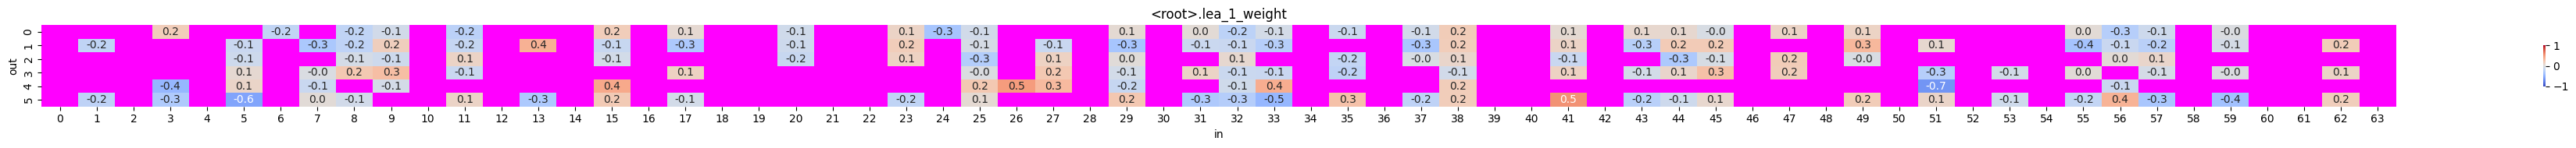

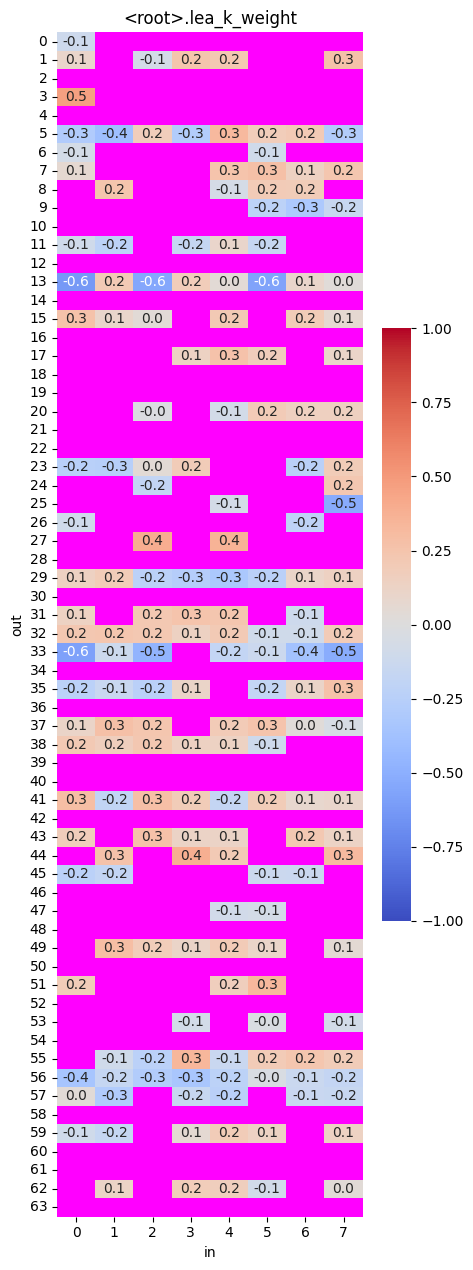

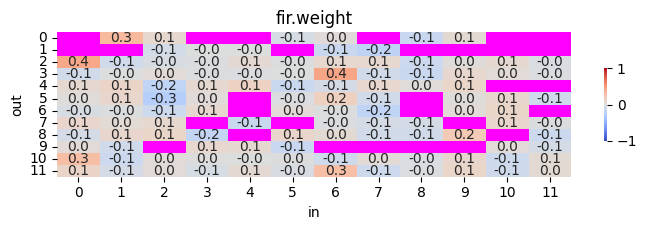

In [13]:
prunning.log_layerwise_sparsity(pleann_dpd_model, only_weights=False)
plotting.plot_weight_heatmaps(pleann_dpd_model, vmin=-1, vmax=1)

LEANN

In [10]:
'''
"L1": 6,
"L2": 64,
"L3": 8,
"K": 2,
'''


leann_train_props = {
    "M": M,
    "L1": 6,
    "L2": 64,
    "L3": 8,
    "K": 2,
    "lr": 0.001,
    "epochs": 300,
    "acpr_meter": acpr_meter
}

leann_pipeline = SimplePipeline(container=container, 
                              train_props=leann_train_props, 
                              base_model=LEANN,
                              pa_model=pa_model)



In [11]:

leann_stats = leann_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

leann_agg_stats = metrics.summarize_statistics(leann_stats)

leann_results = leann_pipeline.get_results()

leann_count = leann_results["ilc"]["count_params"]

final_leann_stats = {
        "Model": "LEANN",
        "Params": leann_count,
        "FLOPs": leann_results["ilc"]["count_flops"],
        "NMSE (dB)": round(leann_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(leann_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(leann_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_leann_stats)


=== Run 1/5 ===
Run ILC
count_params: 1948
count_macs: 3918
count_flops: 27428
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.17273933, val_loss: 0.01094809, val_NMSE: -19.49, lr: 0.001


KeyboardInterrupt: 

RTDTNN

In [7]:
'''
"d_model": 14,
"n_heads": 2,
"d_ff": 12,
"n_fc": 8,
"num_blocks": 1,

nmse: -46
'''


rtdtnn_train_props = {
    "M": M,
    "P": P,
    "d_in": P+2,
    "d_model": 8,
    "n_heads": 1,
    "d_ff": 48,
    "n_fc": 16,
    "num_blocks": 1,
    "lr": 0.001,
    "epochs": 400,
    "acpr_meter": acpr_meter
}

rtdtnn_pipeline = SimplePipeline(container=container, 
                              train_props=rtdtnn_train_props, 
                              base_model=RTDTNN,
                              pa_model=pa_model)


In [8]:

rtdtnn_stats = rtdtnn_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

rtdtnn_agg_stats = metrics.summarize_statistics(rtdtnn_stats)

rtdtnn_results = rtdtnn_pipeline.get_results()

rtdtnn_count = rtdtnn_results["ilc"]["count_params"]

final_rtdtnn_stats = {
        "Model": "RTDTNN",
        "Params": rtdtnn_count,
        "FLOPs": rtdtnn_results["ilc"]["count_flops"],
        "NMSE (dB)": round(rtdtnn_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(rtdtnn_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(rtdtnn_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_rtdtnn_stats)


=== Run 1/5 ===
Run ILC
count_params: 1988
count_macs: 7760
count_flops: 13156
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.23935853, val_loss: 0.02565257, val_NMSE: -15.80, lr: 0.001
Epoch 0001 — train_loss: 0.01347292, val_loss: 0.00845094, val_NMSE: -20.62, lr: 0.001
Epoch 0002 — train_loss: 0.00682649, val_loss: 0.00516601, val_NMSE: -22.76, lr: 0.001
Epoch 0003 — train_loss: 0.00493966, val_loss: 0.00446045, val_NMSE: -23.39, lr: 0.001
Epoch 0004 — train_loss: 0.00386262, val_loss: 0.00302357, val_NMSE: -25.09, lr: 0.001
Epoch 0005 — train_loss: 0.00320270, val_loss: 0.00269359, val_NMSE: -25.58, lr: 0.001
Epoch 0006 — train_loss: 0.00242924, val_loss: 0.00212749, val_NMSE: -26.61, lr: 0.001
Epoch 0007 — train_loss: 0.00204089, val_loss: 0.00162884, val_NMSE: -27.77, lr: 0.001
Epoch 0008 — train_loss: 0.00173815, val_loss: 0.00125482, val_NMSE: -28.90, lr: 0.001
Epoch 0009 — train_loss: 0.00137590, val_loss: 0.00128368, val_NMSE: -28.80, 

In [6]:

rtdtnn_pe_train_props = {
    "M": M,
    "P": P,
    "d_in": P+2,
    "d_model": 8,
    "n_heads": 1,
    "d_ff": 48,
    "n_fc": 16,
    "num_blocks": 1,
    "lr": 0.001,
    "epochs": 400,
    "acpr_meter": acpr_meter
}

rtdtnn_pe_pipeline = SimplePipeline(container=container, 
                              train_props=rtdtnn_pe_train_props, 
                              base_model=RTDTNN,
                              pa_model=pa_model)



rtdtnn_pe_stats = rtdtnn_pe_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

rtdtnn_pe_agg_stats = metrics.summarize_statistics(rtdtnn_pe_stats)

rtdtnn_pe_results = rtdtnn_pe_pipeline.get_results()

rtdtnn_pe_count = rtdtnn_pe_results["ilc"]["count_params"]

final_rtdtnn_pe_stats = {
        "Model": "RTDTNN",
        "Params": rtdtnn_pe_count,
        "FLOPs": rtdtnn_pe_results["ilc"]["count_flops"],
        "MACs": rtdtnn_pe_results["ilc"]["count_macs"],
        "NMSE (dB)": round(rtdtnn_pe_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(rtdtnn_pe_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(rtdtnn_pe_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_rtdtnn_pe_stats)


=== Run 1/5 ===
Run ILC
count_params: 2004
count_macs: 7760
count_flops: 13156
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:57
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:27
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.23110096, val_loss: 0.01619796, val_NMSE: -17.83, lr: 0.001
Epoch 0001 — train_loss: 0.00977985, val_loss: 0.00591893, val_NMSE: -22.17, lr: 0.001
Epoch 0002 — train_loss: 0.00475090, val_loss: 0.00410795, val_NMSE: -23.75, lr: 0.001
Epoch 0003 — train_loss: 0.00340041, val_loss: 0.00276821, val_NMSE: -25.47, lr: 0.001
Epoch 0004 — train_loss: 0.00254771, val_loss: 0.00174721, val_NMSE: -27.46, lr: 0.001
Epoch 0005 — train_loss: 0.00209103, val_loss: 0.00149022, val_NMSE: -28.16, lr: 0.001
Epoch 0006 — train

GRU

In [8]:
gru_train_props = {
    "hidden_size": 24, 
    "num_layers": 1,
    "bidirectional": False,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter
}

gru_pipeline = SimplePipeline(container=container, 
                              train_props=gru_train_props, 
                              base_model=GRU,
                              pa_model=pa_model)


In [ ]:

gru_stats = gru_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

gru_agg_stats = metrics.summarize_statistics(gru_stats)

gru_results = gru_pipeline.get_results()

gru_count = gru_results["ilc"]["count_params"]

final_gru_stats = {
        "Model": "GRU",
        "Params": gru_count,
        "FLOPs": gru_results["ilc"]["count_flops"],
        "NMSE (dB)": round(gru_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(gru_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(gru_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_gru_stats)


=== Run 1/5 ===
Run ILC
count_params: 2066
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:41
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:27
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.03436075, val_loss: 0.00083485, val_NMSE: -30.22, lr: 0.01
Epoch 0001 — train_loss: 0.00146287, val_loss: 0.00033601, val_NMSE: -34.17, lr: 0.01
Epoch 0002 — train_loss: 0.00104116, val_loss: 0.00048323, val_NMSE: -32.59, lr: 0.01
Epoch 0003 — train_loss: 0.00086928, val_loss: 0.00032459, val_NMSE: -34.32, lr: 0.01
Epoch 0004 — train_loss: 0.00078739, val_loss: 0.00021388, val_NMSE: -36.13, lr: 0.01
Epoch 0005 — train_loss: 0.00071985, val_loss: 0.00015534, val_NMSE: -37.52, lr: 0.01
Epoch 0006 — train_loss: 0.00068238, val_loss: 0.00011632, v

LSTM

In [10]:
lstm_train_props = {
    "hidden_size": 20, 
    "num_layers": 1,
    "bidirectional": False,
    "lr": 0.01,
    "epochs": 200,
    "acpr_meter": acpr_meter
}

lstm_pipeline = SimplePipeline(container=container, 
                              train_props=lstm_train_props, 
                              base_model=LSTM,
                              pa_model=pa_model)


In [ ]:

lstm_stats = lstm_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

lstm_agg_stats = metrics.summarize_statistics(lstm_stats)

lstm_results = lstm_pipeline.get_results()

lstm_count = lstm_results["ilc"]["count_params"]

final_lstm_stats = {
        "Model": "LSTM",
        "Params": lstm_count,
        "FLOPs": lstm_results["ilc"]["count_flops"],
        "NMSE (dB)": round(lstm_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(lstm_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(lstm_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_lstm_stats)


=== Run 1/5 ===
Run ILC
count_params: 1962
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.04606683, val_loss: 0.00099525, val_NMSE: -29.45, lr: 0.01
Epoch 0001 — train_loss: 0.00179736, val_loss: 0.00049844, val_NMSE: -32.46, lr: 0.01
Epoch 0002 — train_loss: 0.00132922, val_loss: 0.00041924, val_NMSE: -33.21, lr: 0.01
Epoch 0003 — train_loss: 0.00111268, val_loss: 0.00033137, val_NMSE: -34.23, lr: 0.01
Epoch 0004 — train_loss: 0.00095451, val_loss: 0.00034816, val_NMSE: -34.02, lr: 0.01
Epoch 0005 — train_loss: 0.00086616, val_loss: 0.00026101, val_NMSE: -35.27, lr: 0.01
Epoch 0006 — train_loss: 0.00079391, val_loss: 0.00022592, val_NMSE: -35.89, lr: 0.01
Epoch 0007 — train_loss: 0.00076353, val_loss: 0.00026998, val_NMSE: -35.12, lr: 0.01
Epoch 0008 — train_loss: 0.00072729, val_loss: 0.00023371, val_NMSE: -35.75, lr: 0.01
Epoch 0009 — train_loss: 0.00071577, val_loss: 0.00023811, val_NMSE: -35.67, lr: 0.01
Epoch 0010 — train_loss: 0.00066980,

Metrics

In [19]:
final_gmp_stats = {'Model': 'GMP', 'Params': 2176, "MACs": 5981, "FLOPs": 12736, 'NMSE (dB)': np.float64(-45.68), 'ACPR left (dB)': np.float64(-57.71), 'ACPR right (dB)': np.float64(-57.26)}
final_gru_stats = {'Model': 'GRU', 'Params': 2066, "MACs": 1920, "FLOPs": 4322, 'NMSE (dB)': np.float64(-51.21), 'ACPR left (dB)': np.float64(-62.65), 'ACPR right (dB)': np.float64(-63.33)}
final_kpgru_stats = {'Model': 'KPGRU', 'Params': 2046, "MACs": 2101, "FLOPs": 4317, 'NMSE (dB)': np.float64(-52.56), 'ACPR left (dB)': np.float64(-64.79), 'ACPR right (dB)': np.float64(-66.22)}
final_kplstm_stats = {'Model': 'KPLSTM', 'Params': 2018, "MACs": 2069, "FLOPs": 4285, 'NMSE (dB)': np.float64(-49.72), 'ACPR left (dB)': np.float64(-63.14), 'ACPR right (dB)': np.float64(-64.2)}
final_kptcn_stats = {'Model': 'KPTCN', 'Params': 2036, "MACs": 2129, "FLOPs": 4833, 'NMSE (dB)': np.float64(-54.37), 'ACPR left (dB)': np.float64(-68.1), 'ACPR right (dB)': np.float64(-68.65)}
final_lstm_stats = {'Model': 'LSTM', 'Params': 1962, "MACs": 1800, "FLOPs": 4182, 'NMSE (dB)': np.float64(-48.16), 'ACPR left (dB)': np.float64(-60.39), 'ACPR right (dB)': np.float64(-60.46)}
final_tcn_stats = {'Model': 'TCN', 'Params': 2016, "MACs": 1920, "FLOPs": 6722, 'NMSE (dB)': np.float64(-48.02), 'ACPR left (dB)': np.float64(-61.92), 'ACPR right (dB)': np.float64(-61.55)}
final_rtdtnn_stats = {'Model': 'RTDTNN', 'Params': 1988, "MACs": 7760, 'FLOPs': 17204, 'NMSE (dB)': np.float64(-47.42), 'ACPR left (dB)': np.float64(-60.1), 'ACPR right (dB)': np.float64(-60.01)}
final_leann_stats = {'Model': 'LEANN', 'Params': 1948, "MACs": 4430, "FLOPs": 27940, 'NMSE (dB)': np.float64(-48.76), 'ACPR left (dB)': np.float64(-62.02), 'ACPR right (dB)': np.float64(-62.9)}

final_pleann_stats = {'Model': 'PLEANN', 'Params': 1357, "MACs": 3918, 'FLOPs': 27428, 'NMSE (dB)': -47.79, 'ACPR left (dB)': -62.37, 'ACPR right (dB)': -62.61}


In [30]:

ilc_results = [
    final_gmp_stats, 
    final_gru_stats,
    final_lstm_stats,
    final_rtdtnn_stats,
    final_leann_stats,
    final_pleann_stats,
    final_tcn_stats,
    final_kpgru_stats, 
    final_kplstm_stats,
    final_kptcn_stats,
    ]

df = pd.DataFrame(ilc_results).drop(columns=['FLOPs'])
df = df.sort_values(by=["NMSE (dB)", "ACPR left (dB)", "ACPR right (dB)"], ascending=[False, False, False]).reset_index(drop=True)

print(df)

df.to_excel("model_metrics.xlsx", index=False)

    Model  Params  MACs  NMSE (dB)  ACPR left (dB)  ACPR right (dB)
0     GMP    2176  5981     -45.68          -57.71           -57.26
1  RTDTNN    1988  7760     -47.42          -60.10           -60.01
2  PLEANN    1357  3918     -47.79          -62.37           -62.61
3     TCN    2016  1920     -48.02          -61.92           -61.55
4    LSTM    1962  1800     -48.16          -60.39           -60.46
5   LEANN    1948  4430     -48.76          -62.02           -62.90
6  KPLSTM    2018  2069     -49.72          -63.14           -64.20
7     GRU    2066  1920     -51.21          -62.65           -63.33
8   KPGRU    2046  2101     -52.56          -64.79           -66.22
9   KPTCN    2036  2129     -54.37          -68.10           -68.65


In [25]:
df.head(20)

,Model,Params,MACs,NMSE (dB),ACPR left (dB),ACPR right (dB)
0,KPTCN,2036,2129,-54.37,-68.10,-68.65
1,KPGRU,2046,2101,-52.56,-64.79,-66.22
2,GRU,2066,1920,-51.21,-62.65,-63.33
3,KPLSTM,2018,2069,-49.72,-63.14,-64.20
4,LEANN,1948,4430,-48.76,-62.02,-62.90
5,LSTM,1962,1800,-48.16,-60.39,-60.46
6,TCN,2016,1920,-48.02,-61.92,-61.55
7,PLEANN,1357,3918,-47.79,-62.37,-62.61
8,RTDTNN,1988,7760,-47.42,-60.10,-60.01
9,GMP,2176,5981,-45.68,-57.71,-57.26
